In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_excel('listings - CDMX_clean.xlsx') 
df.head()

,Unnamed: 0,id,host_id,beds,bedrooms,source,name,description,neighborhood_overview,host_name,...,number_of_reviews_ltm,number_of_reviews_l30d,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,reviews_per_month
0,1,44616,196253,1,5,previous scrape,Condesa Haus,A new concept of hosting in mexico through a b...,No neighborhood_overview,Fernando,...,0.0,0.0,4.58,4.56,4.70,4.87,4.78,4.98,4.48,0.41
1,2,67703,334451,2,2,city scrape,"2 bedroom apt. deco bldg, Condesa","Comfortably furnished, sunny, 2 bedroom apt., ...",No neighborhood_overview,Nicholas,...,4.0,0.0,4.90,4.81,4.75,4.94,4.92,4.98,4.91,0.31
2,3,70644,212109,1,1,city scrape,Beautiful light Studio Coyoacan- full equipped !,COYOACAN designer studio quiet & safe! well eq...,Coyoacan is a beautiful neighborhood famous fo...,Trisha,...,7.0,2.0,4.91,4.90,4.96,4.96,4.98,4.96,4.92,0.83
3,4,107078,540705,1,1,city scrape,NEW DESIGNER LOFT,Is the best ever place triple L <br />Location...,"Is located in the best area of Mexico City, Po...",Andrea,...,0.0,0.0,4.91,5.00,5.00,5.00,4.73,4.91,4.82,0.11
4,5,131610,647454,1,2,previous scrape,MARIA DEL ALMA,No description,No neighborhood_overview,Fernando,...,0.0,0.0,4.80,4.80,4.80,4.90,4.90,4.90,4.80,1.17


In [3]:
df = df[df['room_type'] == 'Shared room']

C:\Users\issei\AppData\Local\Temp\ipykernel_36220\3158968366.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


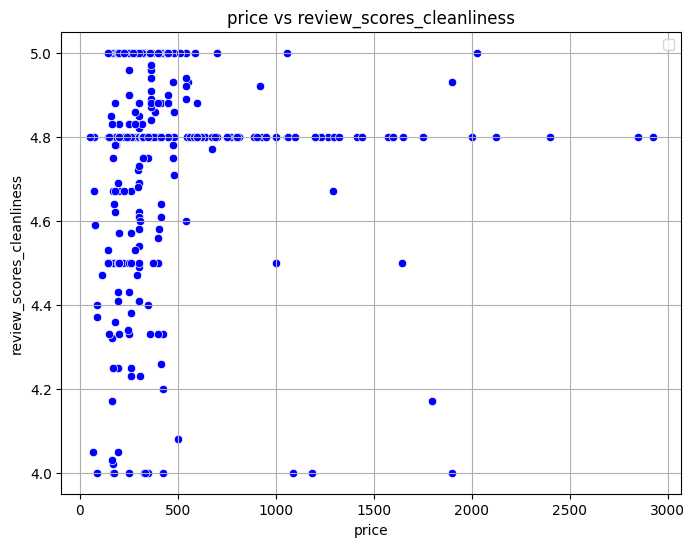

In [4]:
from turtle import color

plt.figure(figsize=(8, 6))
sns.scatterplot(y='review_scores_cleanliness', x='price',  color = 'blue', data=df)
plt.title('price vs review_scores_cleanliness')
plt.xlabel('price')
plt.ylabel('review_scores_cleanliness')
plt.legend()
plt.grid(True)
plt.show()

In [5]:
indep= df[['review_scores_cleanliness']]
dep = df[['price']]

In [6]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

In [7]:
model.fit(indep, dep)

LinearRegression()

In [8]:
type(model)

sklearn.linear_model._base.LinearRegression

In [9]:
model.__dict__

{'fit_intercept': True,
 'copy_X': True,
 'n_jobs': None,
 'positive': False,
 'feature_names_in_': array(['review_scores_cleanliness'], dtype=object),
 'n_features_in_': 1,
 'coef_': array([[58.04741685]]),
 'rank_': 1,
 'singular_': array([4.76950438]),
 'intercept_': array([164.10292725])}

In [10]:
m = model.coef_
b = model.intercept_
print('Pendiente:', m)
print('Intercepto:', b)

# Entonce, el modelo lineal sería:
print(f'y = {m[0]}x + {b}')

Pendiente: [[58.04741685]]
Intercepto: [164.10292725]
y = [58.04741685]x + [164.10292725]


In [11]:
r2 = model.score(indep, dep)
r2

0.0011421944531572192

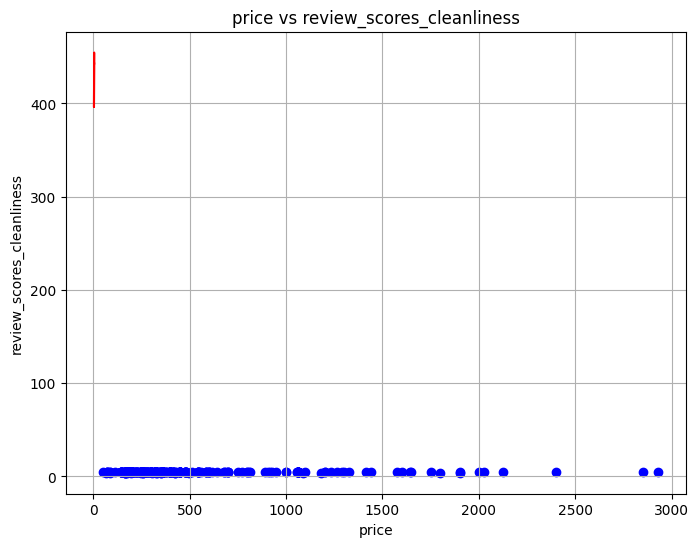

In [12]:
plt.figure(figsize=(8, 6))
plt.scatter(dep, indep, color='blue')
plt.plot(indep, model.predict(indep), color='red')
plt.title('price vs review_scores_cleanliness')
plt.xlabel('price')
plt.ylabel('review_scores_cleanliness')
plt.grid(True)
plt.show()

In [14]:
yPred = model.predict(df[['review_scores_cleanliness']])
yPred

array([[442.73052814],
       [442.73052814],
       [423.57488058],
       [442.73052814],
       [450.27669233],
       [442.73052814],
       [427.63819976],
       [442.73052814],
       [442.73052814],
       [425.31630308],
       [449.69621816],
       [442.73052814],
       [442.73052814],
       [415.44824222],
       [442.73052814],
       [442.73052814],
       [454.34001151],
       [442.73052814],
       [454.34001151],
       [442.73052814],
       [447.37432149],
       [442.73052814],
       [447.37432149],
       [442.73052814],
       [442.73052814],
       [442.73052814],
       [442.73052814],
       [433.44294144],
       [442.73052814],
       [409.64350053],
       [416.02871639],
       [424.73582891],
       [410.80444887],
       [399.1949655 ],
       [442.73052814],
       [454.34001151],
       [421.2529839 ],
       [443.89147648],
       [440.98910563],
       [420.09203557],
       [435.18436395],
       [436.34531228],
       [444.47195064],
       [397

In [15]:
df['Predicciones'] = yPred
df.head()

,Unnamed: 0,id,host_id,beds,bedrooms,source,name,description,neighborhood_overview,host_name,...,number_of_reviews_l30d,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,reviews_per_month,Predicciones
114,115,617137,3059169,1,1,previous scrape,Apt near Mexico City's downtown,No description,No neighborhood_overview,Andoni,...,0.0,4.80,4.80,4.80,4.90,4.90,4.90,4.80,0.135,442.730528
257,258,3197924,16186468,2,2,city scrape,cuarto con terraza y uso general,"double bed , full bathroom, room with own terr...",Condesa is the main attraction in the city for...,Jordi,...,0.0,4.80,4.80,4.80,4.90,4.90,4.90,4.80,1.195,442.730528
365,366,5434219,28190065,18,1,city scrape,メキシコシティの革命記念塔付近のホステルです。,Single Room $30<br />Double room $60<br />Dorm...,No neighborhood_overview,Tetsuo,...,2.0,4.44,4.74,4.47,4.74,4.71,4.71,4.59,0.300,423.574881
443,444,6972071,35406862,16,1,city scrape,SUPER SAVER GROUP DEAL - PERFECT FOR STUDENTS,Welcome to the best college-style dorms in a B...,No neighborhood_overview,Thor,...,0.0,4.80,4.80,4.80,4.90,4.90,4.90,4.80,0.165,442.730528
455,456,6076798,31426842,12,1,city scrape,Nova House,It has all the comforts to rest if you come fo...,The neighborhood is popular where you can expe...,Antonio,...,0.0,4.85,4.84,4.93,4.94,4.91,4.69,4.93,0.750,450.276692


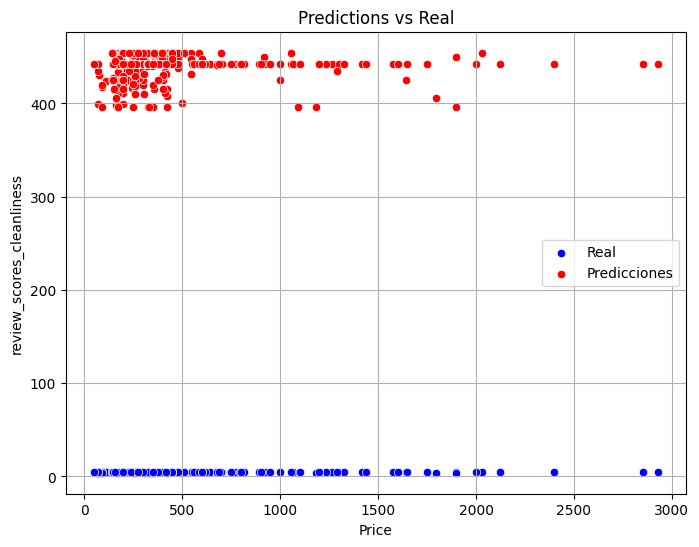

In [16]:
plt.figure(figsize=(8, 6 ))
sns.scatterplot(x='price', y='review_scores_cleanliness', color='blue', data=df, label='Real')
sns.scatterplot(x='price', y='Predicciones', color='red', data=df, label='Predicciones')
#sns.lineplot(x='alcohol', y='Predicciones', color='red', data=df, label='Predicciones')
plt.title('Predictions vs Real')
plt.xlabel('Price')
plt.ylabel('review_scores_cleanliness')
plt.legend()
plt.grid(True)
plt.show()

In [17]:
coefDe = model.score(indep, dep)
coefDe

0.0011421944531572192

In [18]:
coefCo = np.sqrt(coefDe)
coefCo

0.03379636745505675